In [1]:
import pandas as pd
import plotnine as pn
from pathlib import Path
import numpy as np
import os
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import beta

from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)

%load_ext autoreload
%autoreload 2

In [3]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")

In [4]:
sa

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [2]:
import sys
sys.path.append("../")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *


In [126]:
pr_res = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/protrider_summary.csv")

In [3]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"
pr_res_all = load_pr_data("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/protrider_summary.csv")

In [53]:
protein_samples = list(set(pr_res_all["sampleID"]))
protein_proteins = list(set(pr_res_all["proteinID"]))

or_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_or_res_all.tsv", sep="\t")
or_res_all = or_res_all.sort_values("pValue")
or_res_all["geneID_short"] = or_res_all["geneID"].str.split(".").str[0]


or_res_all_pr_subset["geneID_short"] = or_res_all_pr_subset["geneID"].str.split(".").str[0]

or_res_all_pr_subset = or_res_all[(or_res_all["sampleID"].isin(protein_samples))]
or_res_all_pr_subset = or_res_all_pr_subset.merge(gene_annot_dt[["gene_id", "gene_name", "gene_type"]], right_on="gene_id", left_on="geneID")
or_res_all_pr_subset = or_res_all_pr_subset[or_res_all_pr_subset["gene_name"].isin(protein_proteins)]


or_res_all_pr_subset = or_res_all_pr_subset.sort_values("pValue")


In [83]:
# or_res_all_pr_subset.to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_or_res_protrider_subset.tsv", sep="\t")
or_res_all_pr_subset = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_or_res_protrider_subset.tsv", sep="\t")
or_res_all_pr_subset["geneID_short"] = or_res_all_pr_subset["geneID"].str.split(".").str[0]


In [84]:
or_res_all_pr_subset

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [4]:
or_res_outliers_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_outliers.tsv", sep="\t")
or_res_outliers_all["geneID_short"] = or_res_outliers_all["geneID"].str.split(".").str[0]


In [5]:
variant_base_path = Path("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/")
benchmark_criteria = "PROTRIDER"

# Read tables
snv_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_snv_{benchmark_criteria}_aggregated.tsv",
    sep="\t"
)
indel_vep_res = pd.read_csv(
    variant_base_path / f"vep_res_rare_indel_{benchmark_criteria}_aggregated.tsv",
    sep="\t"
)

# Combine
vep_res_combined_protrider = pd.concat([snv_vep_res, indel_vep_res], ignore_index=True)

print(len(vep_res_combined_protrider))

# Unique_based_on_criteria
if benchmark_criteria == "CADD_PHRED":
    # Sort decreasing by CADD_PHRED
    vep_res_combined_protrider = (
        snv_vep_res.sort_values("CADD_PHRED", ascending=False)
        .groupby(["sampleID", "Gene"])
        .head(1)
        .reset_index(drop=True)
    )
else:
    # Set IMPACT as ordered category and sort
    impact_order = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
    vep_res_combined_protrider["IMPACT"] = pd.Categorical(
        vep_res_combined_protrider["IMPACT"],
        categories=impact_order,
        ordered=True
    )

    vep_res_combined_protrider = (
        vep_res_combined_protrider.sort_values(["Gene", "sampleID", "IMPACT"])
    )

# Remove duplicates by Gene + sampleID, keeping first (like data.table)
vep_res_combined_protrider = (
    vep_res_combined_protrider.drop_duplicates(subset=["Gene", "sampleID"])
)
print(len(vep_res_combined_protrider))

5806856
1745352


In [12]:
pr_res_all = pd.merge(pr_res_all, vep_res_combined_protrider[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
pr_res_all["VUS"] = pr_res_all["IMPACT"].notna()

pr_res_aberrant = pr_res_all[pr_res_all["padjust"] <= 0.1
pr_res_aberrant["IMPACT_bool"] = pr_res_aberrant["IMPACT"] == "HIGH"


In [87]:
pr_res_all

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [85]:
or_res_all_pr_subset = pd.merge(or_res_all_pr_subset, vep_res_combined_protrider[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
or_res_all_pr_subset["IMPACT_bool"] = or_res_all_pr_subset["IMPACT"] == "HIGH"
or_res_all_pr_subset["VUS"] = or_res_all_pr_subset["IMPACT"].notna()


In [19]:
or_res_outliers_all = pd.merge(or_res_outliers_all, vep_res_combined_protrider[["Gene", "sampleID", "IMPACT", "Consequence"]], left_on=["geneID_short", "sampleID"], right_on= ["Gene", "sampleID"], how="left")
or_res_outliers_all["IMPACT_bool"] = or_res_outliers_all["IMPACT"] == "HIGH"
or_res_outliers_all["VUS"] = or_res_outliers_all["IMPACT"].notna()


In [108]:
or_res_all_pr_subset["gene_sample"] = or_res_all_pr_subset["gene_name"] + "_" + or_res_all_pr_subset["sampleID"]
pr_res_all["gene_sample"] = pr_res_all["proteinID"] + "_" + pr_res_all["sampleID"]


In [109]:
print(len(or_res_all_pr_subset["sampleID"].unique())) ## 972 samples in RNA
len(pr_res_all["sampleID"].unique()) ## 972 samples in proteomics
len(or_res_all_pr_subset["gene_sample"].unique())

972


6556809

In [111]:
pr_or_merged = pr_res_all.merge(or_res_all_pr_subset, on="gene_sample")


In [113]:
len(pr_or_merged)

6556809

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 233349 rows containing missing values.


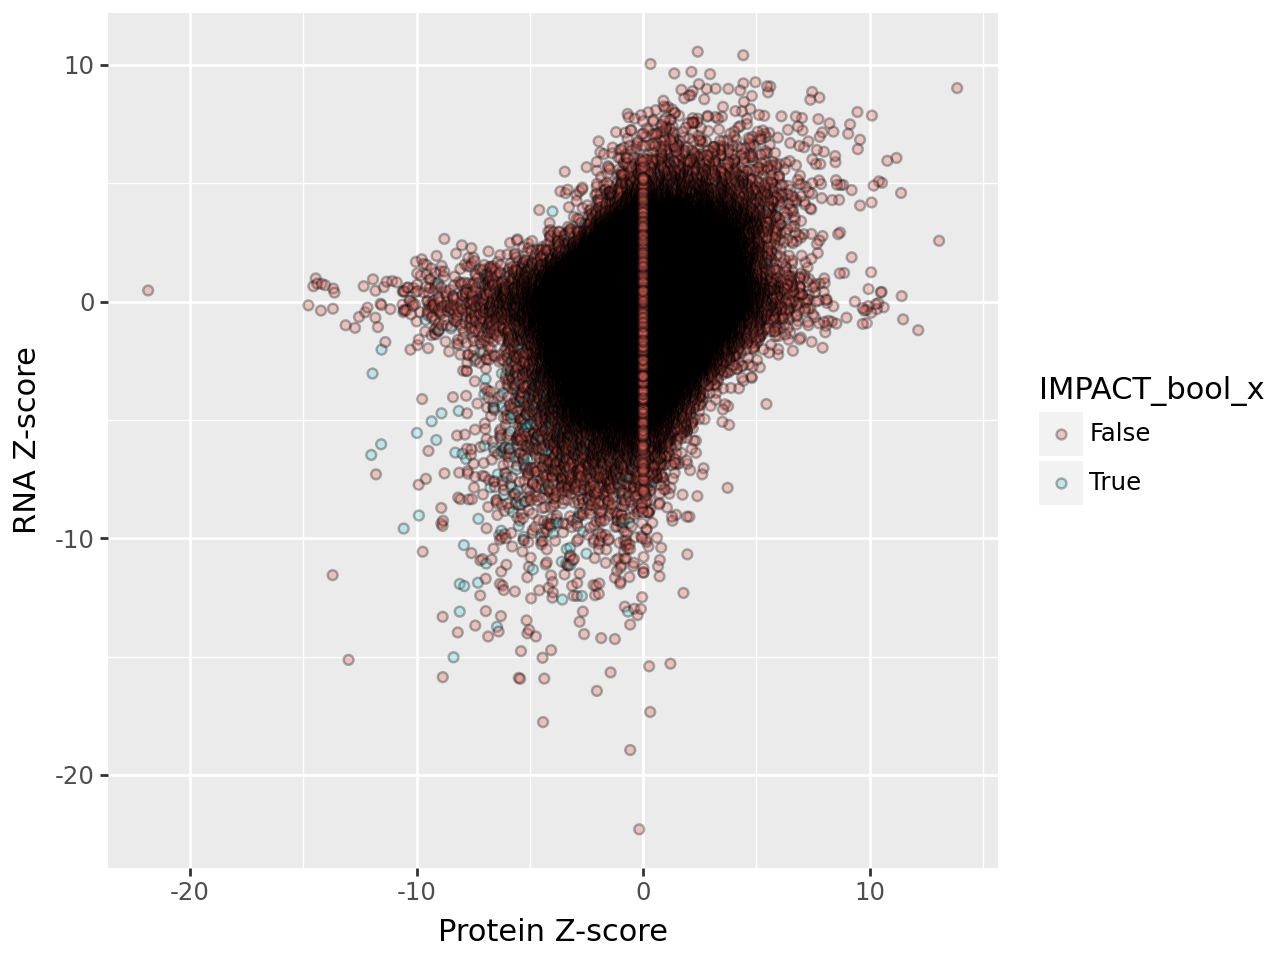

In [112]:
(pn.ggplot(pr_or_merged) + 
     pn.geom_point(pn.aes(x="zScore_x", y="zScore_y", fill="IMPACT_bool_x"), alpha=0.3) +
     pn.labs(x="Protein Z-score", y="RNA Z-score")
     
)

In [116]:
pr_or_merged_aberrant = pr_or_merged[(pr_or_merged["padjust_x"] <= 0.1) | (pr_or_merged["padjust_y"] < 0.05)]

In [155]:
pr_or_merged_aberrant["aberrant_type"] = "NA"

pr_or_merged_aberrant.loc[(pr_or_merged_aberrant["padjust_x"] <= 0.1) & (pr_or_merged_aberrant["padjust_y"] > 0.05), "aberrant_type"] = "Protein"

pr_or_merged_aberrant.loc[(pr_or_merged_aberrant["padjust_x"] <= 0.1) & (pr_or_merged_aberrant["padjust_y"] <= 0.05), "aberrant_type"] = "RNA & protein"


pr_or_merged_aberrant.loc[((pr_or_merged_aberrant["padjust_x"] > 0.1) | (~pr_or_merged_aberrant["padjust_x"].notna())) & (pr_or_merged_aberrant["padjust_y"] <= 0.05), "aberrant_type"] = "RNA"




/tmp/ipykernel_1854045/1350335417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 129 rows containing missing values.


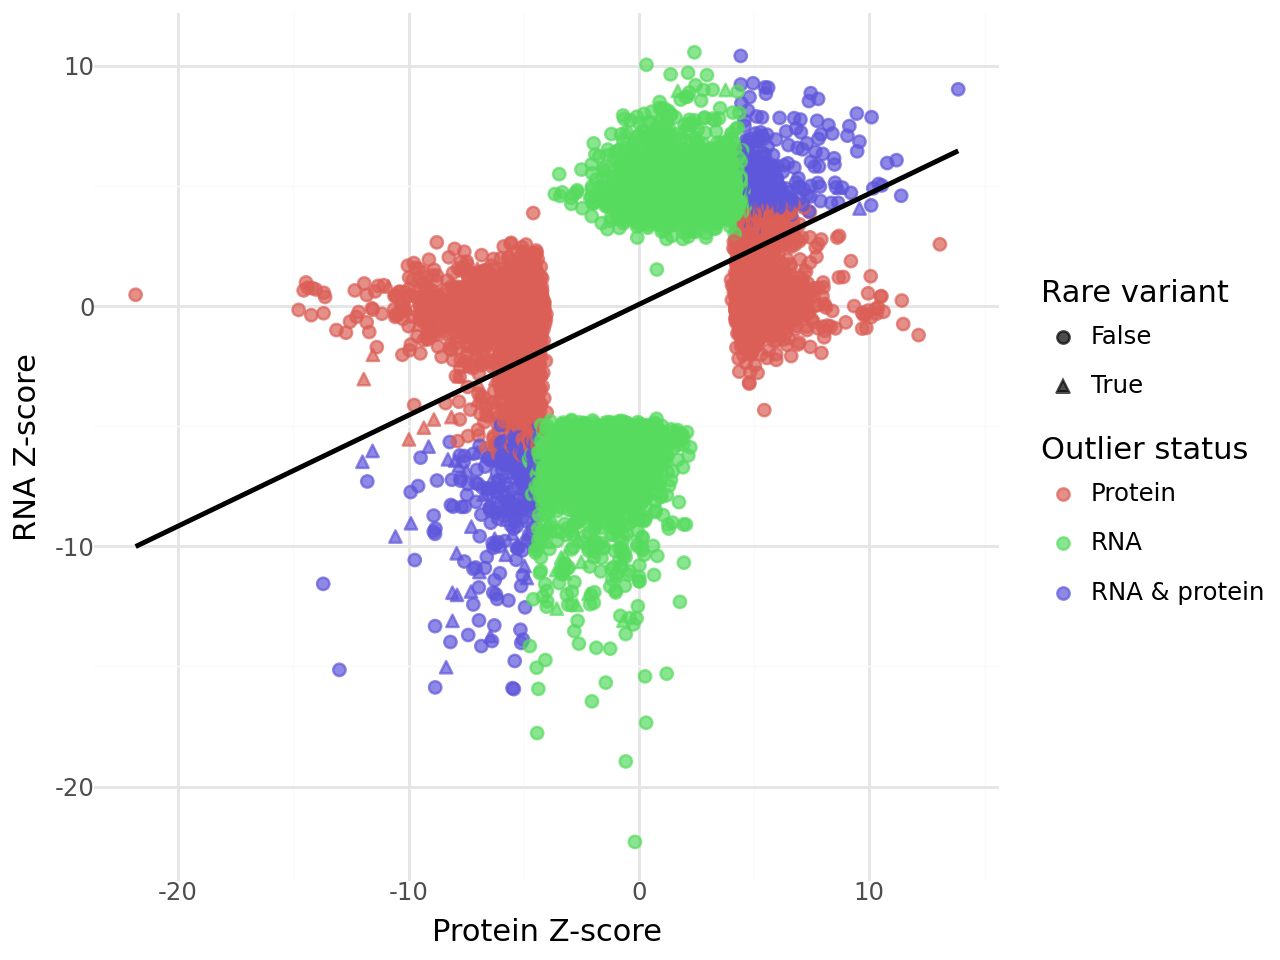

In [192]:
(pn.ggplot(pr_or_merged_aberrant, pn.aes(y="zScore_x", x="zScore_y"), ) + 
     pn.geom_point(pn.aes(shape='VUS_x', color="aberrant_type"), alpha=0.7, size=2) +
     pn.labs(x="RNA Z-score", y="Protein Z-score") + 
     pn.labs(shape="Rare variant", color="Outlier status") +
     pn.theme_minimal() +
     #pn.scale_shape_manual(values={True: 17, False: 16}) +
     pn.geom_smooth(method='lm', se=False)
     
)

In [186]:
pr_or_merged_aberrant.loc[(pr_or_merged_aberrant["IMPACT_y"] != "HIGH") & (pr_or_merged_aberrant["VUS_x"] == True), "variant_type"] = "missense"

/tmp/ipykernel_1854045/1226408653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [187]:
pr_or_merged_aberrant

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


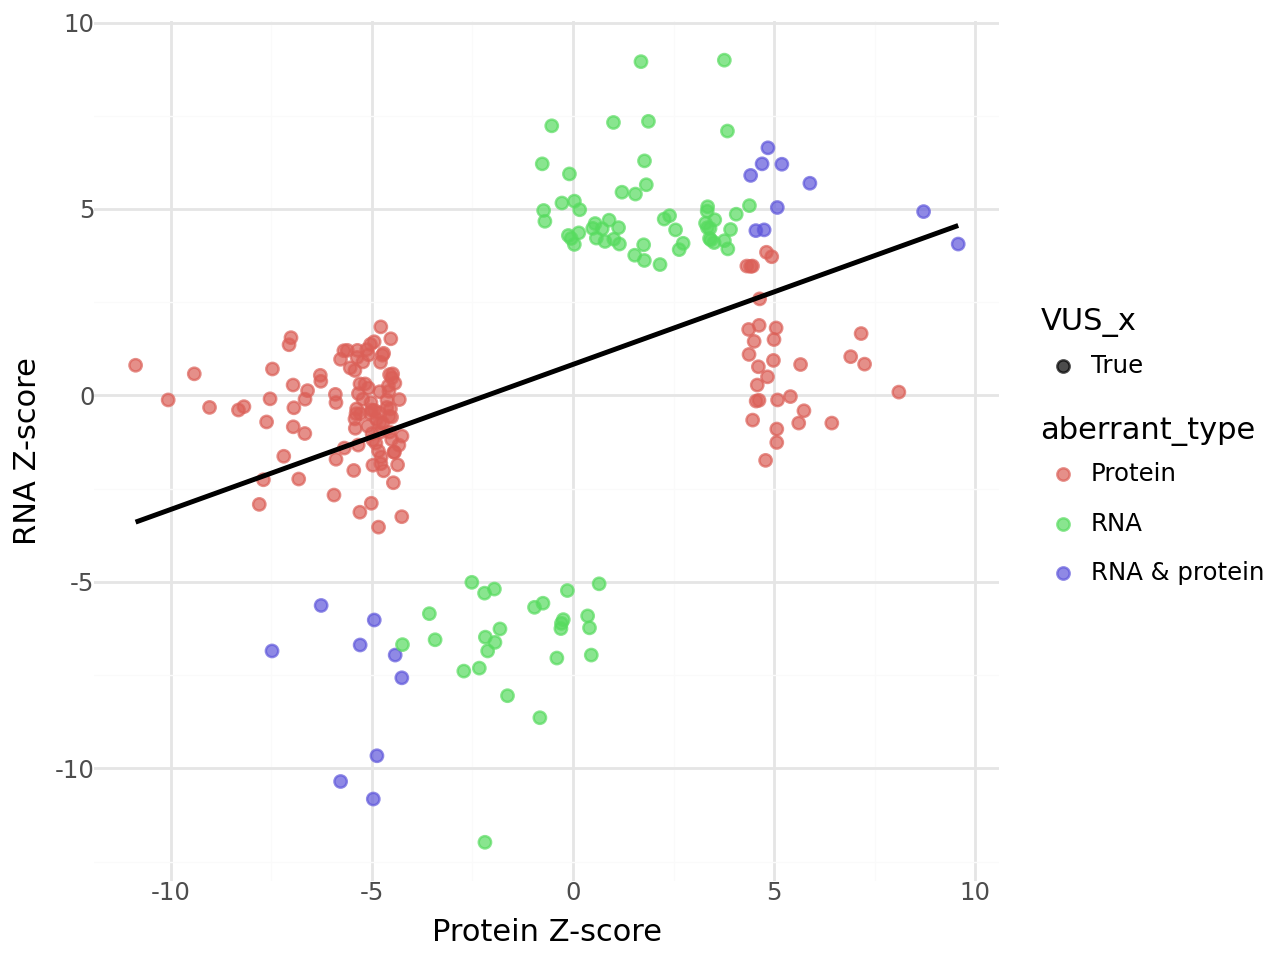

In [188]:
(pn.ggplot(pr_or_merged_aberrant[pr_or_merged_aberrant["variant_type"] == "missense"], pn.aes(x="zScore_x", y="zScore_y"), ) + 
     pn.geom_point(pn.aes(shape='VUS_x', color="aberrant_type"), alpha=0.7, size=2) +
     pn.labs(x="Protein Z-score", y="RNA Z-score") + 
     pn.theme_minimal() +
     #pn.scale_shape_manual(values={True: 17, False: 16}) +
     pn.geom_smooth(method='lm', se=False)
     
)